Using 578 data points for analysis

CORRELATION ANALYSIS RESULTS
Age vs. Accretion Rate:
  Slope: -0.145 (negative = accretion decreases with age)
  Correlation (r): -0.139
  R²: 0.019 (1.9% variance explained)
  p-value: 8.12e-04

Mass vs. Accretion Rate:
  Slope: 0.423 (positive = more massive stars accrete faster)
  Correlation (r): 0.317
  R²: 0.100 (10.0% variance explained)
  p-value: 5.84e-15

Interpretation:
1. Accretion rate declines with stellar age (expected for disk dissipation)
2. Higher mass stars have higher accretion rates (expected from gravitational potential)


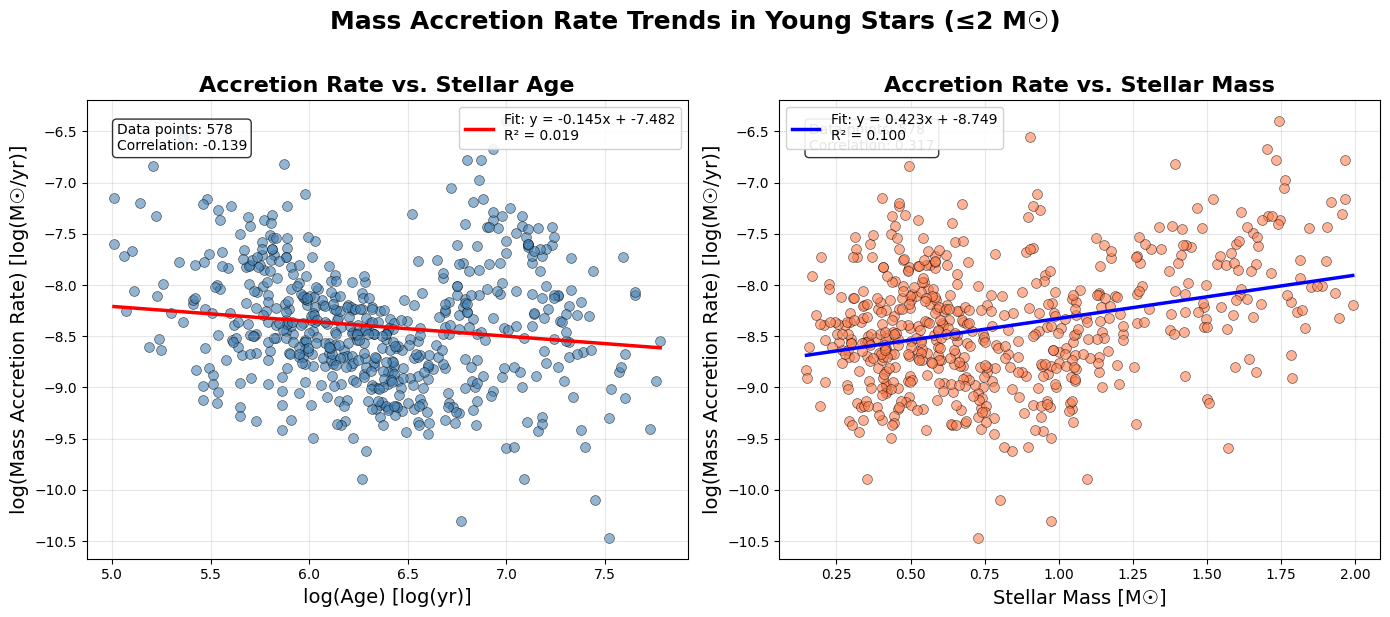

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load data
file_path = 'compilation_Venuti_2024_Serna_2021.csv'
df = pd.read_csv(file_path)

# Filter for stars ≤2 solar masses and clean data
df = df[df['Mstar'] <= 2.0]
df = df.dropna(subset=['logAge', 'Mstar', 'logMacc'])

print(f"Using {len(df)} data points for analysis")

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ============================================
# Plot 1: Age vs Accretion Rate
# ============================================
ax1.scatter(df['logAge'], df['logMacc'], 
            alpha=0.6, s=50, c='steelblue', edgecolors='black', linewidth=0.5)

# Add best fit line (simple linear regression)
x_age = df['logAge'].values
y_macc = df['logMacc'].values
slope_age, intercept_age, r_value_age, p_value_age, std_err_age = linregress(x_age, y_macc)

# Generate fit line points
x_fit_age = np.linspace(x_age.min(), x_age.max(), 100)
y_fit_age = slope_age * x_fit_age + intercept_age

ax1.plot(x_fit_age, y_fit_age, 'r-', linewidth=2.5, 
         label=f'Fit: y = {slope_age:.3f}x + {intercept_age:.3f}\nR² = {r_value_age**2:.3f}')

# Customize plot
ax1.set_xlabel('log(Age) [log(yr)]', fontsize=14)
ax1.set_ylabel('log(Mass Accretion Rate) [log(M☉/yr)]', fontsize=14)
ax1.set_title('Accretion Rate vs. Stellar Age', fontsize=16, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=10, framealpha=0.9)

# Add statistics box
stats_text = f'Data points: {len(df)}\nCorrelation: {r_value_age:.3f}'
ax1.text(0.05, 0.95, stats_text, transform=ax1.transAxes,
         verticalalignment='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ============================================
# Plot 2: Mass vs Accretion Rate
# ============================================
ax2.scatter(df['Mstar'], df['logMacc'], 
            alpha=0.6, s=50, c='coral', edgecolors='black', linewidth=0.5)

# Add best fit line (simple linear regression)
x_mass = df['Mstar'].values
slope_mass, intercept_mass, r_value_mass, p_value_mass, std_err_mass = linregress(x_mass, y_macc)

# Generate fit line points
x_fit_mass = np.linspace(x_mass.min(), x_mass.max(), 100)
y_fit_mass = slope_mass * x_fit_mass + intercept_mass

ax2.plot(x_fit_mass, y_fit_mass, 'b-', linewidth=2.5, 
         label=f'Fit: y = {slope_mass:.3f}x + {intercept_mass:.3f}\nR² = {r_value_mass**2:.3f}')

# Customize plot
ax2.set_xlabel('Stellar Mass [M☉]', fontsize=14)
ax2.set_ylabel('log(Mass Accretion Rate) [log(M☉/yr)]', fontsize=14)
ax2.set_title('Accretion Rate vs. Stellar Mass', fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left', fontsize=10, framealpha=0.9)

# Add statistics box
stats_text = f'Data points: {len(df)}\nCorrelation: {r_value_mass:.3f}'
ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes,
         verticalalignment='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ============================================
# Final touches
# ============================================
plt.suptitle('Mass Accretion Rate Trends in Young Stars (≤2 M☉)', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

# Display correlation results
print("\n" + "="*60)
print("CORRELATION ANALYSIS RESULTS")
print("="*60)
print(f"Age vs. Accretion Rate:")
print(f"  Slope: {slope_age:.3f} (negative = accretion decreases with age)")
print(f"  Correlation (r): {r_value_age:.3f}")
print(f"  R²: {r_value_age**2:.3f} ({r_value_age**2*100:.1f}% variance explained)")
print(f"  p-value: {p_value_age:.2e}")

print(f"\nMass vs. Accretion Rate:")
print(f"  Slope: {slope_mass:.3f} (positive = more massive stars accrete faster)")
print(f"  Correlation (r): {r_value_mass:.3f}")
print(f"  R²: {r_value_mass**2:.3f} ({r_value_mass**2*100:.1f}% variance explained)")
print(f"  p-value: {p_value_mass:.2e}")

print(f"\nInterpretation:")
print(f"1. Accretion rate declines with stellar age (expected for disk dissipation)")
print(f"2. Higher mass stars have higher accretion rates (expected from gravitational potential)")

# Show the plots
plt.show()